<a href="https://colab.research.google.com/github/Projeto-Aplicado-IV/previsao-e-analise-series-temporais-foco-queimadas-brasil/blob/main/cd_projeto_aplicado_IV_doc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/02**


# **Documentação do Projeto**

---

# **Produto Analítico: Previsão de Focos de Queimadas como Suporte à Gestão de Risco de Desastres em Municípios Brasileiros (ODS 11)**
---

In [1]:
#@title **Identificação do Grupo**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'Gustavo Azevedo Gomyde, 10424543' #@param {type:"string"}
Aluno2 = 'Karla Maria Ramos da Silva, 10441405' #@param {type:"string"}
Aluno3 = 'Luana Isabella Xavier Porto, 10443026' #@param {type:"string"}
Aluno4 = 'Rafael Hessel Sichetti, 10375395' #@param {type:"string"}

# **Resumo**

Este trabalho propõe um produto analítico de caracterização e previsão da série temporal de focos de queimadas no Brasil, a partir dos dados abertos do Programa Queimadas do INPE, como apoio ao planejamento de órgãos de defesa civil e brigadas municipais de incêndio, em alinhamento ao ODS 11 (Cidades e Comunidades Sustentáveis). A metodologia agrega os focos detectados por satélite em contagens mensais, caracteriza tendência, sazonalidade e ruído por meio de análise exploratória e decomposição, e compara um baseline sazonal, um modelo estatístico (SARIMA) e uma rede neural recorrente (LSTM) em validação temporal, com as métricas MAE e RMSE. Os resultados da comparação e o modelo de melhor desempenho serão apresentados nas etapas finais do projeto.

# **Introdução**

As séries temporais permitem caracterizar o comportamento de um fenômeno ao longo do tempo e apoiar decisões futuras (MORETTIN; TOLOI, 2018). Este projeto aplica essa abordagem à série de focos de queimadas no território brasileiro, monitorada pelo Instituto Nacional de Pesquisas Espaciais por meio do Programa Queimadas (INPE, 2026), no contexto da gestão de risco de desastres e do planejamento urbano. O trabalho se alinha ao Objetivo de Desenvolvimento Sustentável 11 (ODS 11), cuja meta 11.5 propõe reduzir mortes e perdas econômicas causadas por desastres e cuja meta 11.b trata do gerenciamento holístico do risco de desastres em todos os níveis de governo (IPEA, [s.d.]). O problema abordado é a dificuldade de antecipar a distribuição temporal dos focos de calor ao longo dos meses e anos, o que limita o planejamento de defesa civil e de brigadas municipais.

Estudos anteriores demonstram que o número de focos pode ser modelado estatisticamente, com SARIMA em Mato Grosso (ESPINOSA; PRADO; GHELLERE, 2010) e com redes neurais no Pantanal (VIGANÓ et al., 2017), mas concentram-se em recortes regionais e em uma lente predominantemente ambiental, com pouca conexão com a resposta a desastres em nível municipal. O **objetivo geral** é desenvolver um produto analítico de previsão e caracterização da série temporal de focos de queimadas no Brasil, como apoio à gestão de risco de desastres em nível municipal. Os **objetivos específicos** são: (i) caracterizar a série quanto à tendência, sazonalidade e ruído; (ii) definir e comparar técnicas de modelagem estatística e de aprendizado de máquina adequadas à série; e (iii) construir um modelo preditivo do volume futuro de focos, com métricas de apoio à decisão. A base de dados explorada é o banco de focos do Programa Queimadas do INPE, descrita na seção de EDA.

A **justificativa** é que antecipar cenários de incidência contribui para a meta 11.5 ao subsidiar o planejamento logístico das brigadas e a alocação de recursos públicos nos períodos de maior risco (IPEA, [s.d.]). Ao disponibilizar código e resultados publicamente, o projeto também favorece a replicação da metodologia por gestores municipais com poucos recursos analíticos, atendendo ao caráter extensionista do componente curricular.

# **Referencial Teórico**

**Conceitos.** Uma série temporal é um conjunto de observações coletadas em intervalos regulares, cuja análise busca descrever o fenômeno e prever valores futuros (MORETTIN; TOLOI, 2018). Costuma-se decompô-la em tendência, sazonalidade, ciclos e ruído, em esquema aditivo ou multiplicativo, sendo o segundo indicado quando a amplitude sazonal cresce com o nível da série (HYNDMAN; ATHANASOPOULOS, 2021). As funções de autocorrelação (ACF) e de autocorrelação parcial (PACF) revelam dependências entre defasagens e orientam a escolha da ordem dos modelos. Já a estacionariedade, isto é, média e variância constantes, pode ser verificada pelo teste ADF (DICKEY; FULLER, 1979) e alcançada por diferenciação ou por transformações como a de Box-Cox (BOX; COX, 1964). O ARIMA combina termos autorregressivos e de médias móveis sobre a série diferenciada, e sua extensão sazonal, o SARIMA, incorpora o período sazonal (BOX et al., 2015). Redes neurais recorrentes, em especial a LSTM, aprendem dependências de longo prazo por meio de células com memória e portas de controle, sem pressupor linearidade (HOCHREITER; SCHMIDHUBER, 1997). Os modelos são comparados por erros como MAE e RMSE, sempre com separação temporal entre treino e teste.

**Trabalhos correlacionados.** Espinosa, Prado e Ghellere (2010) ajustaram um SARIMA à contagem de focos em Mato Grosso, obtendo previsões adequadas para os meses críticos, de junho a outubro. Viganó et al. (2017) aplicaram redes neurais MLP ao Pantanal e obtiveram ajuste de 99,4% ao usar apenas a própria série de focos como preditora. Pinheiro e Rodrigues (2024) previram os focos do Brasil entre 2011 e 2022 de forma hierárquica (país, bioma e município), comparando ARIMA, ETS e Prophet com técnicas de reconciliação. Tavares e Olinda (2024) combinaram LSTM e GRU para prever os acumulados mensais de focos na Amazônia, verificando a captura da sazonalidade. Silva (2026) comparou XGBoost e LSTM no Pantanal: o XGBoost teve menores MAE e RMSE, e a LSTM captou a sazonalidade, mas teve dificuldade em reproduzir a magnitude de eventos extremos.

**Vantagens e limitações.** Os modelos estatísticos (SARIMA, ETS) são interpretáveis, funcionam bem com séries curtas e fornecem intervalos de previsão, mas assumem relações lineares e estáveis no tempo. Os modelos de aprendizado de máquina capturam relações não lineares e aceitam variáveis exógenas, como clima e risco de fogo, porém exigem mais dados e ajuste de hiperparâmetros e são menos interpretáveis. Além disso, os estudos citados concentram-se em recortes regionais ou em bioma, e poucos conectam a previsão ao planejamento da resposta municipal. Este projeto busca preencher essa lacuna comparando SARIMA e LSTM contra um baseline sazonal, sobre a série nacional e municípios selecionados, com foco no apoio à decisão (ODS 11).

# **Diagrama de Solução**

O diagrama abaixo apresenta o pipeline proposto, que segue as etapas clássicas da análise de séries temporais (coleta, pré-processamento, análise exploratória, modelagem e avaliação) e termina em um produto voltado à decisão.

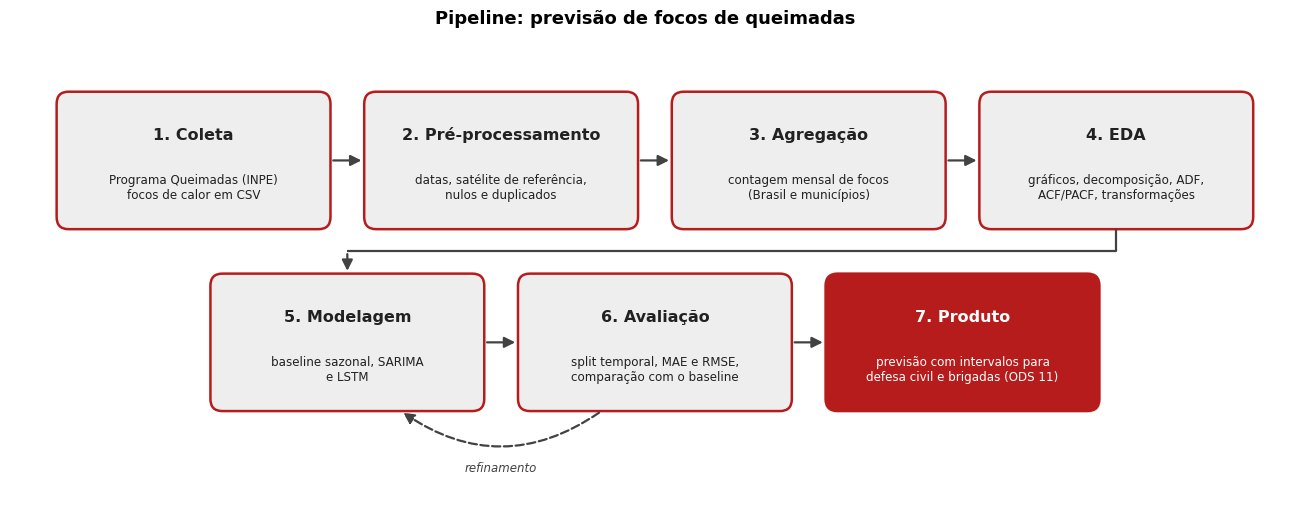

In [2]:
#@title **Pipeline da solução**
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

etapas = [
    ("1. Coleta",             "Programa Queimadas (INPE)\nfocos de calor em CSV"),
    ("2. Pré-processamento",  "datas, satélite de referência,\nnulos e duplicados"),
    ("3. Agregação",          "contagem mensal de focos\n(Brasil e municípios)"),
    ("4. EDA",                "gráficos, decomposição, ADF,\nACF/PACF, transformações"),
    ("5. Modelagem",          "baseline sazonal, SARIMA\ne LSTM"),
    ("6. Avaliação",          "split temporal, MAE e RMSE,\ncomparação com o baseline"),
    ("7. Produto",            "previsão com intervalos para\ndefesa civil e brigadas (ODS 11)"),
]
pos = [(0.5, 2.2), (3.6, 2.2), (6.7, 2.2), (9.8, 2.2),
       (2.05, 0.4), (5.15, 0.4), (8.25, 0.4)]
w, h = 2.7, 1.3

fig, ax = plt.subplots(figsize=(13, 5.2))
ax.set_xlim(0, 12.8); ax.set_ylim(-0.5, 4.1); ax.axis("off")

for i, ((titulo, desc), (x, y)) in enumerate(zip(etapas, pos)):
    cor = "#B71C1C" if i == len(etapas) - 1 else "#EEEEEE"
    txt = "white" if i == len(etapas) - 1 else "#212121"
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.03,rounding_size=0.12",
                                fc=cor, ec="#B71C1C", lw=1.8))
    ax.text(x + w/2, y + h*0.70, titulo, ha="center", va="center", fontsize=11.5,
            fontweight="bold", color=txt)
    ax.text(x + w/2, y + h*0.30, desc, ha="center", va="center", fontsize=8.6, color=txt)

def seta(p, q, style="-|>", rad=0.0, ls="-"):
    ax.add_patch(FancyArrowPatch(p, q, arrowstyle=style, mutation_scale=16, lw=1.6,
                                 color="#424242", connectionstyle=f"arc3,rad={rad}", linestyle=ls))

# linha 1 -> linha 2 (etapas 1 a 4)
for i in range(3):
    seta((pos[i][0] + w + 0.03, pos[i][1] + h/2), (pos[i+1][0] - 0.03, pos[i+1][1] + h/2))
# quebra de linha: etapa 4 -> etapa 5
xa, xb, ym = pos[3][0] + w/2, pos[4][0] + w/2, 1.95
ax.plot([xa, xa, xb], [pos[3][1] - 0.03, ym, ym], color="#424242", lw=1.6, solid_capstyle="butt")
seta((xb, ym), (xb, pos[4][1] + h + 0.03))
# linha 2 (etapas 5 a 7)
for i in (4, 5):
    seta((pos[i][0] + w + 0.03, pos[i][1] + h/2), (pos[i+1][0] - 0.03, pos[i+1][1] + h/2))
# ciclo de refinamento avaliação -> modelagem
seta((pos[5][0] + w*0.3, pos[5][1] - 0.03), (pos[4][0] + w*0.7, pos[4][1] - 0.03), rad=-0.35, ls="--")
ax.text((pos[4][0] + pos[5][0] + w) / 2, -0.12, "refinamento", ha="center", va="top",
        fontsize=8.5, style="italic", color="#424242")

ax.set_title("Pipeline: previsão de focos de queimadas", fontsize=13, fontweight="bold", pad=8)
plt.tight_layout()
plt.show()

**Discussão do pipeline.**

1. **Coleta:** obtenção dos focos de calor no banco de dados abertos do Programa Queimadas do INPE (INPE, 2026), em nível de foco individual, com data e hora, localização (município, estado e bioma) e satélite.
2. **Pré-processamento:** conversão de datas, tratamento de valores nulos e duplicados e escolha de um único satélite de referência, para que a contagem não mude por troca de sensor ao longo do tempo. Meses sem focos são mantidos com valor zero, preservando o espaçamento regular da série.
3. **Agregação:** contagem mensal de focos, para o Brasil e para municípios selecionados. A frequência mensal reduz o ruído diário e é a mesma adotada em trabalhos correlacionados (ESPINOSA; PRADO; GHELLERE, 2010; TAVARES; OLINDA, 2024).
4. **EDA:** gráficos de linha, boxplot por mês e mapa de calor ano × mês; decomposição para separar tendência, sazonalidade e resíduo; teste ADF e gráficos ACF/PACF; transformação de Box-Cox ou logarítmica se a variância crescer com o nível da série.
5. **Modelagem:** um baseline sazonal ingênuo (repete o mesmo mês do ano anterior) serve de referência mínima. Sobre ele são ajustados um SARIMA, com ordem guiada por ACF/PACF e critério de informação, e uma LSTM com janela deslizante.
6. **Avaliação:** divisão estritamente temporal em treino, validação e teste, sem embaralhar as observações, com validação em janela expansível. As métricas são MAE e RMSE, que toleram meses com zero focos, ao contrário do MAPE. O resultado alimenta o refinamento dos modelos.
7. **Produto:** previsão dos meses seguintes com intervalos de incerteza e indicação dos meses de maior risco, em formato de relatório e visualização que órgãos de defesa civil e brigadas municipais possam usar no planejamento.

# **Cronograma**

O cronograma abrange todas as atividades planejadas até a entrega final, e não apenas os marcos da disciplina. As datas em negrito são as entregas oficiais.

| Período | Atividade |
| --- | --- |
| 21/09 a 25/09 | Redação e revisão do Referencial Teórico e do pipeline; migração do notebook para o template; conferência das referências (ABNT) e commit no GitHub |
| **28/09** | **Entrega da Etapa 2** |
| 29/09 a 06/10 | Coleta da base no INPE (definir recorte temporal e satélite de referência); pré-processamento e agregação mensal (Brasil e municípios selecionados) |
| 07/10 a 13/10 | EDA: gráficos, decomposição, teste ADF, ACF/PACF e transformações |
| 14/10 a 20/10 | Implementação dos modelos: baseline sazonal, SARIMA e LSTM |
| 21/10 a 22/10 | Avaliação (MAE e RMSE) e comparação entre os modelos |
| 23/10 a 25/10 | Documentação da Etapa 3 no notebook e revisão do repositório |
| **26/10** | **Entrega da Etapa 3** |
| 27/10 a 06/11 | Refinamento dos modelos (hiperparâmetros) e estudo de caso em municípios selecionados |
| 09/11 a 13/11 | Análise crítica dos modelos, discussão do melhor resultado e proposição de melhorias futuras |
| 16/11 a 20/11 | Elaboração dos slides e do roteiro da apresentação |
| 21/11 a 25/11 | Gravação e edição do vídeo; inclusão do link no notebook |
| 26/11 a 29/11 | Documentação final, README e organização do repositório; revisão geral pelo grupo |
| **30/11** | **Entrega final (Etapa 4)** |

# **EDA e Pré-processamento dos dados**

## Base de dados

A base provém do banco de dados abertos do INPE, por meio do Programa Queimadas (INPE, 2026): dados reais e públicos, usados como referência em estudos correlatos (ESPINOSA; PRADO; GHELLERE, 2010; VIGANÓ et al., 2017). A amostragem original é diária, no nível de foco de calor individual, com os atributos abaixo.

| **Atributo** | **Descrição / Tipo** |
| --- | --- |
| data_hora_gmt | Data e hora da detecção do foco, fundamental para a ordenação dos registros no tempo. |
| lat e lon | Coordenadas geográficas do evento (latitude e longitude). |
| satelite | Sensor de captura da imagem (ex.: GOES-19). |
| municipio, estado, bioma | Dados categóricos e de agrupamento espacial, essenciais para o recorte municipal proposto. |
| precipitacao, risco_fogo, numero_dias_sem_chuva, frp | Fatores meteorológicos associados e poder radiativo do fogo no instante da detecção. |

Os dados são coletados de forma contínua por sensoriamento remoto via satélite (INPE, 2026). Para construir a série temporal univariada, os registros pontuais e irregulares serão agrupados em contagens mensais de focos, para o Brasil e por município, resultando em uma sequência de observações igualmente espaçadas no tempo, abordagem semelhante à de Espinosa, Prado e Ghellere (2010).

**Fonte:** Portal INPE, Estatísticas e Dados Abertos do Programa Queimadas (INPE, 2026).

## Exploração inicial

A célula abaixo ilustra a rotina planejada de carga e agregação dos dados. A execução completa, com a análise exploratória e a modelagem, será desenvolvida na Etapa 3.

In [3]:
import pandas as pd

# Fonte oficial dos dados abertos do Programa Queimadas (INPE, 2026)
# Documentação: https://terrabrasilis.dpi.inpe.br/queimadas/portal/

URL_BASE = "https://terrabrasilis.dpi.inpe.br/queimadas/dados/"  # placeholder de documentação

# Exemplo ilustrativo de leitura de um recorte já exportado do portal
# (a ser substituído pelo arquivo real na Etapa 3):
# df = pd.read_csv("focos_br_2026.csv")
# df["data_hora_gmt"] = pd.to_datetime(df["data_hora_gmt"])
# df_mensal = (
#     df.groupby([df["data_hora_gmt"].dt.to_period("M"), "municipio"])
#       .size()
#       .rename("numero_focos")
#       .reset_index()
# )
# df_mensal.head()

print("Rotina de carga e agregação mensal por município: a ser executada com os dados completos na Etapa 3.")

Rotina de carga e agregação mensal por município: a ser executada com os dados completos na Etapa 3.


# **Modelos**

*Seção a ser desenvolvida na Etapa 3 (26/10).*

In [4]:
# Códigos aqui (Etapa 3)

# **Resultados**

*Seção a ser desenvolvida nas Etapas 3 e 4.*

# **Dicussão e Conclusão**

*Seção a ser desenvolvida na Etapa 4 (30/11).*

# **Apresentação**

*Links do vídeo de apresentação (com apoio de slides) a serem incluídos na Etapa 4.*

# **Referências**

BOX, G. E. P.; COX, D. R. An analysis of transformations. **Journal of the Royal Statistical Society, Series B**, v. 26, n. 2, p. 211-252, 1964.

BOX, G. E. P.; JENKINS, G. M.; REINSEL, G. C.; LJUNG, G. M. **Time series analysis**: forecasting and control. 5. ed. Hoboken: Wiley, 2015.

DICKEY, D. A.; FULLER, W. A. Distribution of the estimators for autoregressive time series with a unit root. **Journal of the American Statistical Association**, v. 74, n. 366, p. 427-431, 1979.

ESPINOSA, M. M.; PRADO, S. M.; GHELLERE, M. Uso do modelo SARIMA na previsão do número de focos de calor para os meses de junho a outubro no Estado de Mato Grosso. **Ciência e Natura**, Santa Maria, v. 32, n. 2, p. 7-21, 2010.

HOCHREITER, S.; SCHMIDHUBER, J. Long short-term memory. **Neural Computation**, v. 9, n. 8, p. 1735-1780, 1997.

HYNDMAN, R. J.; ATHANASOPOULOS, G. **Forecasting**: principles and practice. 3. ed. Melbourne: OTexts, 2021. Disponível em: https://otexts.com/fpp3/.

INSTITUTO DE PESQUISA ECONÔMICA APLICADA (IPEA). **ODS 11 — Cidades e Comunidades Sustentáveis**. Objetivos de Desenvolvimento Sustentável. [s.d.]. Disponível em: https://www.ipea.gov.br/ods/ods11.html. Acesso em: 1 set. 2026.

INSTITUTO NACIONAL DE PESQUISAS ESPACIAIS (INPE). **Programa Queimadas**: banco de dados de focos. Dados abertos governamentais. Disponível em: https://terrabrasilis.dpi.inpe.br/queimadas/portal/. Acesso em: 31 ago. 2026.

MORETTIN, P. A.; TOLOI, C. M. C. **Análise de séries temporais**. 3. ed. São Paulo: Blucher, 2018.

PINHEIRO, A. C.; RODRIGUES, P. C. Hierarchical time series forecasting of fire spots in Brazil: a comprehensive approach. **Stats**, Basel, v. 7, n. 3, p. 647-670, 2024. DOI: 10.3390/stats7030039.

SILVA, R. A. da. **Previsão de séries temporais de queimadas no Pantanal com uso de aprendizado de máquina**. 2026. Trabalho de Conclusão de Curso (Graduação em Engenharia de Computação) — Universidade Federal de São Carlos, São Carlos, 2026. Disponível em: https://repositorio.ufscar.br/handle/20.500.14289/23861.

TAVARES, R. L. O.; OLINDA, R. A. **Redes neurais com LSTM e GRU na modelagem de focos ativos na Amazônia**. arXiv:2409.02681, 2024. Disponível em: https://arxiv.org/abs/2409.02681.

VIGANÓ, H. H. da G.; SOUZA, C. C. de; CRISTALDO, M. F.; JESUS, L. de. Redes neurais artificiais na previsão de queimadas e incêndios no Pantanal. **Revista Brasileira de Geografia Física**, v. 10, n. 5, p. 1355-1367, 2017.